In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import unidecode

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

np.set_printoptions(precision=4, suppress=True)

def print_metrics(name, y_true, y_pred, cm_labels=None):
    print(f"\n=== {name} ===")
    print(classification_report(y_true, y_pred, digits=4))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred, labels=cm_labels))

df = pd.read_excel('dados_tuberculose_mg.xlsx')

def limpar_texto(x):
    if pd.isna(x):
        return x
    x = str(x).strip()
    x = unidecode.unidecode(x)
    x = x.replace(" ", "_")
    return x

colunas_categoricas = df.select_dtypes(include=["object"]).columns

for col in colunas_categoricas:
    df[col] = df[col].apply(limpar_texto)

categorias_validas = ["Cura", "Obito_por_TB", "Obito_por_outras_causas", "Abandono"]
df_processado = df[df["SITUA_ENCE"].isin(categorias_validas)].copy()

df_processado["DT_DIAG"] = pd.to_datetime(df_processado["DT_DIAG"], format="%d/%m/%Y", errors="coerce")
df_processado["DT_INIC_TR"] = pd.to_datetime(df_processado["DT_INIC_TR"], format="%d/%m/%Y", errors="coerce")
df_processado["tempo_inicio_trat"] = (df_processado["DT_INIC_TR"] - df_processado["DT_DIAG"]).dt.days

df_processado = df_processado.drop_duplicates()
df_processado["tempo_inicio_trat"] = df_processado["tempo_inicio_trat"].fillna(df_processado["tempo_inicio_trat"].median())

colunas_alta_card = ["ID_MUNICIP", "ID_UNIDADE", "ID_MN_RESI"]
for col in colunas_alta_card:
    freq = df_processado[col].value_counts(normalize=True)
    df_processado[f"{col}_FREQ"] = df_processado[col].map(freq)

features_categoricas_baixa = [
    "ID_REGIONA", "CS_SEXO", "CS_RACA", "CS_ESCOL_N", "TRATAMENTO", "CULTURA_ES",
    "HISTOPATOL", "FORMA", "AGRAVAIDS", "AGRAVALCOO", "AGRAVDIABE",
    "AGRAVDOENC", "AGRAVOUTRA", "HIV"
]

features_numericas = ["NU_IDADE_N", "tempo_inicio_trat"] + [f"{col}_FREQ" for col in colunas_alta_card]

X = df_processado[features_categoricas_baixa + features_numericas]
y = df_processado["SITUA_ENCE"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=43,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train distribution:\n", y_train.value_counts(normalize=True).round(4))
print("Test distribution:\n", y_test.value_counts(normalize=True).round(4))

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), features_categoricas_baixa),
        ("num", StandardScaler(), features_numericas)
    ]
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=43)

#=========================
#randomforest
#=========================
rf_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=43,
        class_weight="balanced"
    ))
])

scores_rf = cross_val_score(rf_pipeline, X_train, y_train, cv=cv, scoring="f1_weighted")
print("\nCV Random Forest (no SMOTE):", scores_rf)
print("Mean CV:", round(scores_rf.mean(), 4))

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
print_metrics("Random Forest (Test)", y_test, y_pred_rf)

rf_pipeline_smote = ImbPipeline(steps=[
    ("preprocess", preprocessor),
    ("balance", SMOTE(random_state=43)),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=43,
        class_weight="balanced"
    ))
])

scores_rf_smote = cross_val_score(rf_pipeline_smote, X_train, y_train, cv=cv, scoring="f1_weighted")
print("\nCV Random Forest (with SMOTE):", scores_rf_smote)
print("Mean CV:", round(scores_rf_smote.mean(), 4))

rf_pipeline_smote.fit(X_train, y_train)
y_pred_rf_smote = rf_pipeline_smote.predict(X_test)
print_metrics("Random Forest with SMOTE (Test)", y_test, y_pred_rf_smote)

#=========================
#xgboost
#=========================
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        random_state=43,
        eval_metric="mlogloss"
    ))
])

scores_xgb = cross_val_score(xgb_pipeline, X_train, y_train_enc, cv=cv, scoring="f1_weighted")
print("\nCV XGBoost (no SMOTE):", scores_xgb)
print("Mean CV:", round(scores_xgb.mean(), 4))

xgb_pipeline.fit(X_train, y_train_enc)
y_pred_xgb = xgb_pipeline.predict(X_test)
print_metrics("XGBoost (Test)", y_test_enc, y_pred_xgb, cm_labels=range(len(le.classes_)))

xgb_pipeline_smote = ImbPipeline(steps=[
    ("preprocess", preprocessor),
    ("balance", SMOTE(random_state=43)),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        random_state=43,
        eval_metric="mlogloss"
    ))
])

scores_xgb_smote = cross_val_score(xgb_pipeline_smote, X_train, y_train_enc, cv=cv, scoring="f1_weighted")
print("\nCV XGBoost (with SMOTE):", scores_xgb_smote)
print("Mean CV:", round(scores_xgb_smote.mean(), 4))

xgb_pipeline_smote.fit(X_train, y_train_enc)
y_pred_xgb_smote = xgb_pipeline_smote.predict(X_test)
print_metrics("XGBoost with SMOTE (Test)", y_test_enc, y_pred_xgb_smote, cm_labels=range(len(le.classes_)))

#=========================
#catboost
#=========================
cat_pipeline = ImbPipeline(steps=[
    ("preprocess", preprocessor),
    ("model", CatBoostClassifier(
        iterations=300,
        learning_rate=0.1,
        depth=6,
        random_state=43,
        verbose=0,
        loss_function="MultiClass"
    ))
])

scores_cat = cross_val_score(cat_pipeline, X_train, y_train_enc, cv=cv, scoring="f1_weighted")
print("\nCV CatBoost (no SMOTE):", scores_cat)
print("Mean CV:", round(scores_cat.mean(), 4))

cat_pipeline.fit(X_train, y_train_enc)
y_pred_cat = cat_pipeline.predict(X_test)
print_metrics("CatBoost (Test)", y_test_enc, y_pred_cat, cm_labels=range(len(le.classes_)))

cat_pipeline_smote = ImbPipeline(steps=[
    ("preprocess", preprocessor),
    ("balance", SMOTE(random_state=43)),
    ("model", CatBoostClassifier(
        iterations=300,
        learning_rate=0.1,
        depth=6,
        random_state=43,
        verbose=0,
        loss_function="MultiClass"
    ))
])

scores_cat_smote = cross_val_score(cat_pipeline_smote, X_train, y_train_enc, cv=cv, scoring="f1_weighted")
print("\nCV CatBoost (with SMOTE):", scores_cat_smote)
print("Mean CV:", round(scores_cat_smote.mean(), 4))

cat_pipeline_smote.fit(X_train, y_train_enc)
y_pred_cat_smote = cat_pipeline_smote.predict(X_test)
print_metrics("CatBoost with SMOTE (Test)", y_test_enc, y_pred_cat_smote, cm_labels=range(len(le.classes_)))

#=========================
#lightgbm
#=========================
lgbm_pipeline = ImbPipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LGBMClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=-1,
        random_state=43,
        objective="multiclass",
        class_weight="balanced"
    ))
])

scores_lgbm = cross_val_score(lgbm_pipeline, X_train, y_train_enc, cv=cv, scoring="f1_weighted")
print("\nCV LightGBM (no SMOTE):", scores_lgbm)
print("Mean CV:", round(scores_lgbm.mean(), 4))

lgbm_pipeline.fit(X_train, y_train_enc)
y_pred_lgbm = lgbm_pipeline.predict(X_test)
print_metrics("LightGBM (Test)", y_test_enc, y_pred_lgbm, cm_labels=range(len(le.classes_)))

lgbm_pipeline_smote = ImbPipeline(steps=[
    ("preprocess", preprocessor),
    ("balance", SMOTE(random_state=43)),
    ("model", LGBMClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=-1,
        random_state=43,
        objective="multiclass",
        class_weight="balanced"
    ))
])

scores_lgbm_smote = cross_val_score(lgbm_pipeline_smote, X_train, y_train_enc, cv=cv, scoring="f1_weighted")
print("\nCV LightGBM (with SMOTE):", scores_lgbm_smote)
print("Mean CV:", round(scores_lgbm_smote.mean(), 4))

lgbm_pipeline_smote.fit(X_train, y_train_enc)
y_pred_lgbm_smote = lgbm_pipeline_smote.predict(X_test)
print_metrics("LightGBM with SMOTE (Test)", y_test_enc, y_pred_lgbm_smote, cm_labels=range(len(le.classes_)))

Train shape: (42924, 19)
Test shape: (10732, 19)
Train distribution:
 SITUA_ENCE
Cura                       0.7377
Abandono                   0.1459
Obito_por_outras_causas    0.0655
Obito_por_TB               0.0510
Name: proportion, dtype: float64
Test distribution:
 SITUA_ENCE
Cura                       0.7377
Abandono                   0.1459
Obito_por_outras_causas    0.0654
Obito_por_TB               0.0510
Name: proportion, dtype: float64

CV Random Forest (no SMOTE): [0.6749 0.6804 0.6822 0.6761 0.6765]
Mean CV: 0.678

=== Random Forest (Test) ===
                         precision    recall  f1-score   support

               Abandono     0.5230    0.1596    0.2446      1566
                   Cura     0.7621    0.9704    0.8537      7917
           Obito_por_TB     0.5116    0.0402    0.0746       547
Obito_por_outras_causas     0.4031    0.0741    0.1252       702

               accuracy                         0.7461     10732
              macro avg     0.5499    0.3111  

=== RandomForest ===
                         precision    recall  f1-score   support

               Abandono       0.52      0.16      0.24      1566
                   Cura       0.76      0.97      0.85      7917
           Obito_por_TB       0.51      0.04      0.07       547
Obito_por_outras_causas       0.40      0.07      0.13       702

               accuracy                           0.75     10732
              macro avg       0.55      0.31      0.32     10732
           weighted avg       0.69      0.75      0.68     10732



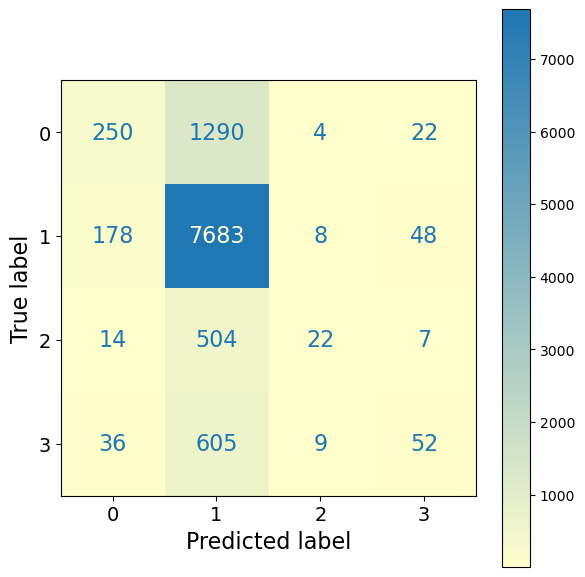


=== XGBoost ===
                         precision    recall  f1-score   support

               Abandono       0.51      0.18      0.27      1566
                   Cura       0.77      0.96      0.86      7917
           Obito_por_TB       0.53      0.12      0.20       547
Obito_por_outras_causas       0.37      0.12      0.18       702

               accuracy                           0.75     10732
              macro avg       0.55      0.35      0.38     10732
           weighted avg       0.70      0.75      0.69     10732



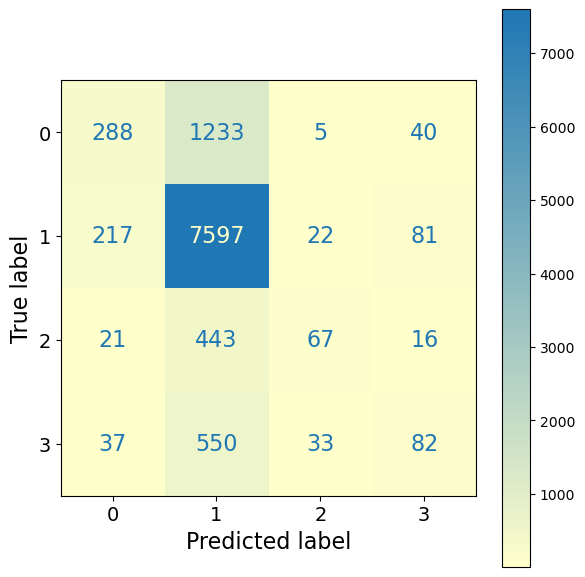


=== RandomForest (com SMOTE) ===
                         precision    recall  f1-score   support

               Abandono       0.40      0.24      0.30      1566
                   Cura       0.79      0.91      0.84      7917
           Obito_por_TB       0.33      0.13      0.18       547
Obito_por_outras_causas       0.31      0.20      0.24       702

               accuracy                           0.72     10732
              macro avg       0.46      0.37      0.39     10732
           weighted avg       0.68      0.72      0.69     10732



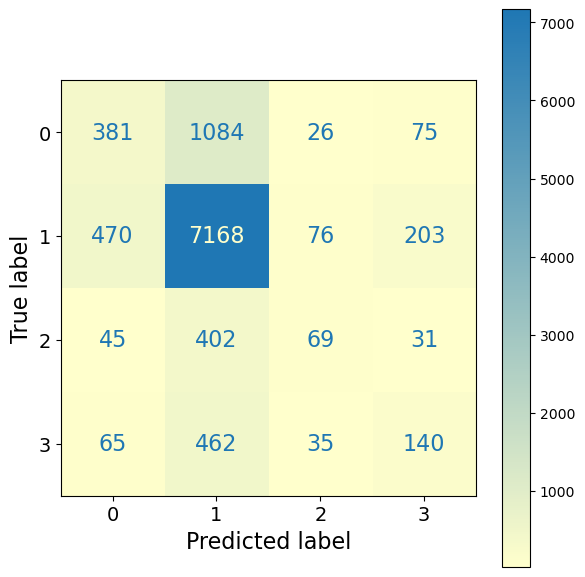


=== XGBoost (com SMOTE) ===
                         precision    recall  f1-score   support

               Abandono       0.47      0.24      0.31      1566
                   Cura       0.79      0.93      0.85      7917
           Obito_por_TB       0.39      0.13      0.20       547
Obito_por_outras_causas       0.37      0.21      0.26       702

               accuracy                           0.74     10732
              macro avg       0.50      0.38      0.41     10732
           weighted avg       0.69      0.74      0.70     10732



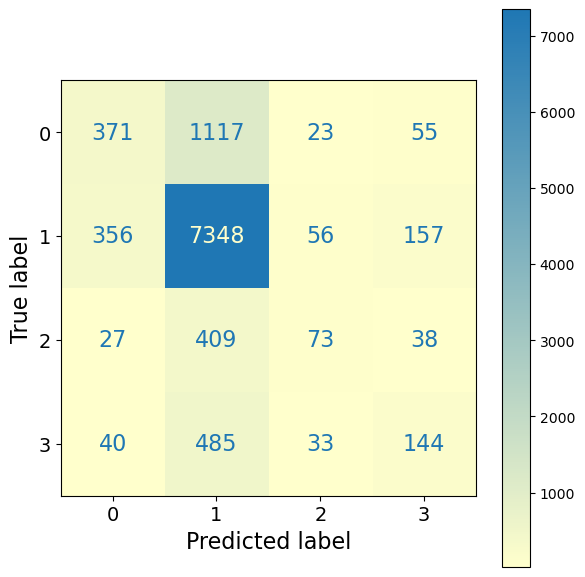


=== CatBoost (NO SMOTE) ===
                         precision    recall  f1-score   support

               Abandono       0.55      0.18      0.27      1566
                   Cura       0.77      0.97      0.86      7917
           Obito_por_TB       0.59      0.09      0.15       547
Obito_por_outras_causas       0.41      0.10      0.16       702

               accuracy                           0.75     10732
              macro avg       0.58      0.33      0.36     10732
           weighted avg       0.70      0.75      0.69     10732



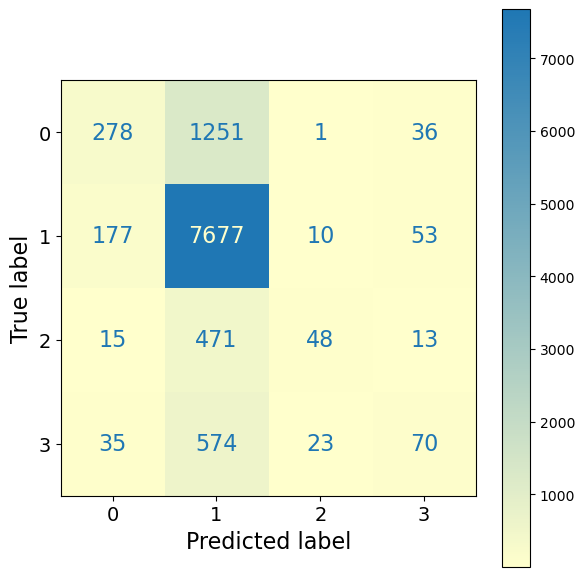

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002874 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 997
[LightGBM] [Info] Number of data points in the train set: 42924, number of used features: 88
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294

=== LightGBM (NO SMOTE) ===
                         precision    recall  f1-score   support

               Abandono       0.32      0.49      0.39      1566
                   Cura       0.87      0.64      0.73      7917
           Obito_por_TB       0.20      0.44      0.27       547
Obito_por_outras_causas       0.22      0.43      0.29       702

               accuracy                           0.59     10732
           

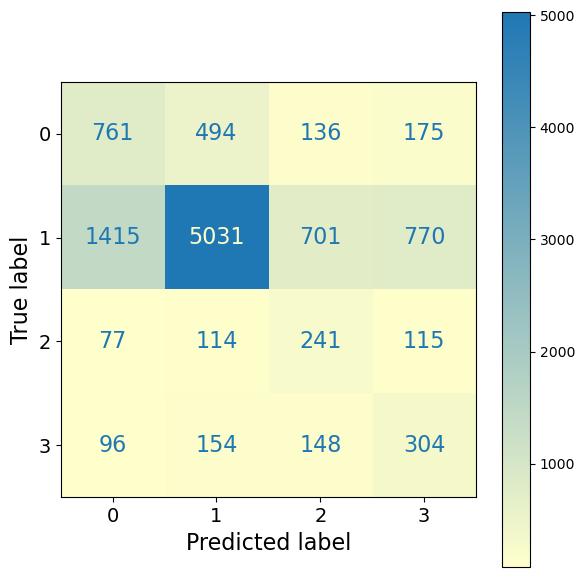


=== CatBoost + SMOTE ===
                         precision    recall  f1-score   support

               Abandono       0.44      0.27      0.33      1566
                   Cura       0.79      0.91      0.85      7917
           Obito_por_TB       0.33      0.15      0.20       547
Obito_por_outras_causas       0.33      0.23      0.27       702

               accuracy                           0.73     10732
              macro avg       0.47      0.39      0.41     10732
           weighted avg       0.69      0.73      0.70     10732



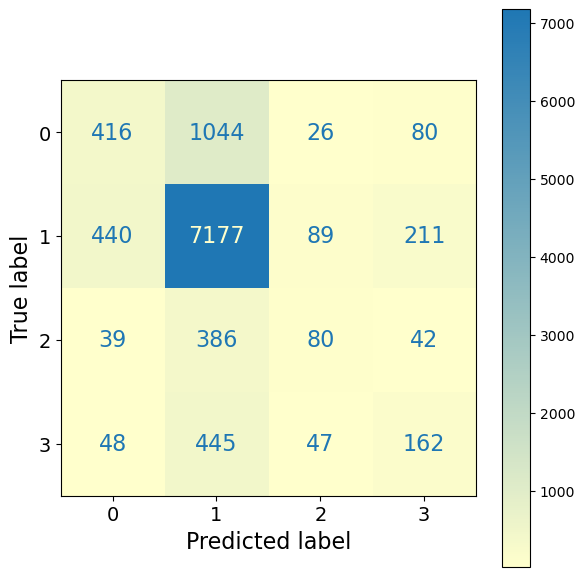

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018532 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 22308
[LightGBM] [Info] Number of data points in the train set: 126652, number of used features: 88
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294

=== LightGBM + SMOTE ===
                         precision    recall  f1-score   support

               Abandono       0.48      0.22      0.30      1566
                   Cura       0.78      0.94      0.85      7917
           Obito_por_TB       0.44      0.12      0.19       547
Obito_por_outras_causas       0.36      0.18      0.24       702

               accuracy                           0.74     10732
           

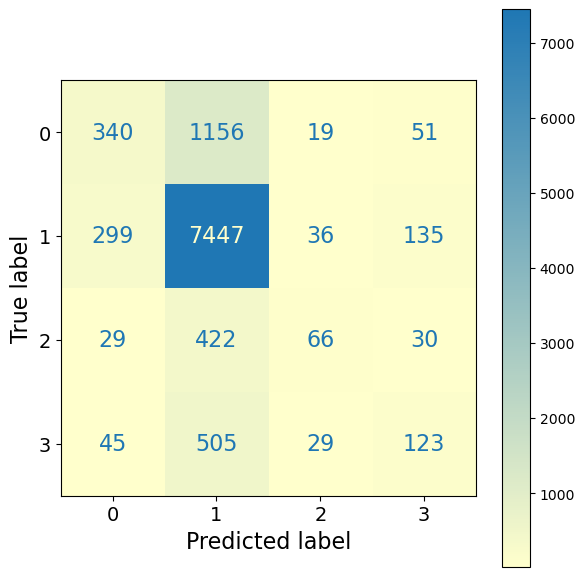

In [4]:
from sklearn.metrics import ConfusionMatrixDisplay

custom_cmap = LinearSegmentedColormap.from_list("YellowBlue", ["#ffffcc", "#1f77b4"])

def plot_confusion_matrix(cm, filename):
    fig, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    ax.grid(False)
    
    disp.plot(cmap=custom_cmap, values_format='d', ax=ax, colorbar=True)
    
    ax.set_xlabel("Predicted label", fontsize=16)
    ax.set_ylabel("True label", fontsize=16)
    ax.tick_params(axis='both', labelsize=14)

    for text in disp.text_.ravel():
        text.set_fontsize(16)

    plt.tight_layout()
    plt.savefig(f"{filename}.pdf", format="pdf", bbox_inches="tight")

    plt.show()

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
print("=== RandomForest ===")
print(classification_report(y_test, y_pred_rf))
cm_rf = confusion_matrix(y_test, y_pred_rf)
plot_confusion_matrix(cm_rf, "confusion_matrix_rf")

xgb_pipeline.fit(X_train, y_train_enc)
y_pred_xgb = xgb_pipeline.predict(X_test)
print("\n=== XGBoost ===")
print(classification_report(y_test_enc, y_pred_xgb, target_names=le.classes_))
cm_xgb = confusion_matrix(y_test_enc, y_pred_xgb)
plot_confusion_matrix(cm_xgb, "confusion_matrix_xgb")

rf_pipeline_smote.fit(X_train, y_train)
y_pred_rf_smote = rf_pipeline_smote.predict(X_test)
print("\n=== RandomForest (com SMOTE) ===")
print(classification_report(y_test, y_pred_rf_smote))
cm_rf_smote = confusion_matrix(y_test, y_pred_rf_smote)
plot_confusion_matrix(cm_rf_smote, "confusion_matrix_rf_smote")

xgb_pipeline_smote.fit(X_train, y_train_enc)
y_pred_xgb_smote = xgb_pipeline_smote.predict(X_test)
print("\n=== XGBoost (com SMOTE) ===")
print(classification_report(y_test_enc, y_pred_xgb_smote, target_names=le.classes_))
cm_xgb_smote = confusion_matrix(y_test_enc, y_pred_xgb_smote)
plot_confusion_matrix(cm_xgb_smote, "confusion_matrix_xgb_smote")

cat_pipeline.fit(X_train, y_train_enc)
y_pred_cat_no_smote = cat_pipeline.predict(X_test)
print("\n=== CatBoost (NO SMOTE) ===")
print(classification_report(y_test_enc, y_pred_cat_no_smote, target_names=le.classes_))
cm_cat_no_smote = confusion_matrix(y_test_enc, y_pred_cat_no_smote)
plot_confusion_matrix(cm_cat_no_smote, "confusion_matrix_cat")

lgbm_pipeline.fit(X_train, y_train_enc)
y_pred_lgbm_no_smote = lgbm_pipeline.predict(X_test)
print("\n=== LightGBM (NO SMOTE) ===")
print(classification_report(y_test_enc, y_pred_lgbm_no_smote, target_names=le.classes_))
cm_lgbm_no_smote = confusion_matrix(y_test_enc, y_pred_lgbm_no_smote)
plot_confusion_matrix(cm_lgbm_no_smote, "confusion_matrix_lgbm")

cat_pipeline_smote.fit(X_train, y_train_enc)
y_pred_cat_smote = cat_pipeline_smote.predict(X_test)
print("\n=== CatBoost + SMOTE ===")
print(classification_report(y_test_enc, y_pred_cat_smote, target_names=le.classes_))
cm_cat_smote = confusion_matrix(y_test_enc, y_pred_cat_smote)
plot_confusion_matrix(cm_cat_smote, "confusion_matrix_cat_smote")

lgbm_pipeline_smote.fit(X_train, y_train_enc)
y_pred_lgbm_smote = lgbm_pipeline_smote.predict(X_test)
print("\n=== LightGBM + SMOTE ===")
print(classification_report(y_test_enc, y_pred_lgbm_smote, target_names=le.classes_))
cm_lgbm_smote = confusion_matrix(y_test_enc, y_pred_lgbm_smote)
plot_confusion_matrix(cm_lgbm_smote, "confusion_matrix_lgbm_smote")

In [6]:
import numpy as np
from scipy import stats

print("\n" + "="*60)
print("FINAL EXPERIMENT REPORT")
print("="*60)

def print_class_distribution(y, title):
    print(f"\n--- {title} ---")
    counts = y.value_counts()
    total = len(y)
    
    for cls, count in counts.items():
        pct = (count / total) * 100
        print(f"Class {cls}: {count} ({pct:.2f}%)")
    
    print(f"Total: {total}")

#=========================
#dataset info
#=========================
print("\n--- DATASET INFORMATION ---")
print("Number of samples:", df_processado.shape[0])
print("Number of features:", X.shape[1])

print("Numerical features:", len(features_numericas))
print("Categorical features:", len(features_categoricas_baixa))

missing_values = df_processado.isna().sum().sum()
print("Total missing values:", missing_values)

#=========================
#class distribution
#=========================
print_class_distribution(y_train, "Train")
print_class_distribution(y_test, "Test")

#=========================
#smote distribution
#=========================
X_train_pre = preprocessor.fit_transform(X_train)

smote = SMOTE(random_state=43)
X_res, y_res = smote.fit_resample(X_train_pre, y_train)

y_res_series = pd.Series(y_res)

print_class_distribution(y_res_series, "Train after SMOTE")

#=========================
#cross-validation
#=========================
def print_cv_stats(name, scores):
    mean = scores.mean()
    std = scores.std()
    
    conf_int = stats.t.interval(
        confidence=0.95,
        df=len(scores)-1,
        loc=mean,
        scale=stats.sem(scores)
    )
    
    print(f"\n--- {name} ---")
    print("Scores:", np.round(scores, 4))
    print(f"Mean: {mean:.4f}")
    print(f"Std: {std:.4f}")
    print(f"95% Confidence Interval: ({conf_int[0]:.4f}, {conf_int[1]:.4f})")

print("\n--- CROSS-VALIDATION STATISTICS ---")

print_cv_stats("Random Forest (no SMOTE)", scores_rf)
print_cv_stats("Random Forest (with SMOTE)", scores_rf_smote)

print_cv_stats("XGBoost (no SMOTE)", scores_xgb)
print_cv_stats("XGBoost (with SMOTE)", scores_xgb_smote)

print_cv_stats("CatBoost (no SMOTE)", scores_cat)
print_cv_stats("CatBoost (with SMOTE)", scores_cat_smote)

print_cv_stats("LightGBM (no SMOTE)", scores_lgbm)
print_cv_stats("LightGBM (with SMOTE)", scores_lgbm_smote)

#=========================
#smote info
#=========================
print("\n--- SMOTE CONFIGURATION ---")
print("Technique: Oversampling")
print("k_neighbors: 5 (default)")
print("Sampling strategy: auto (minority classes upsampled)")


FINAL EXPERIMENT REPORT

--- DATASET INFORMATION ---
Number of samples: 53656
Number of features: 19
Numerical features: 5
Categorical features: 14
Total missing values: 1595

--- Train ---
Class Cura: 31663 (73.77%)
Class Abandono: 6262 (14.59%)
Class Obito_por_outras_causas: 2810 (6.55%)
Class Obito_por_TB: 2189 (5.10%)
Total: 42924

--- Test ---
Class Cura: 7917 (73.77%)
Class Abandono: 1566 (14.59%)
Class Obito_por_outras_causas: 702 (6.54%)
Class Obito_por_TB: 547 (5.10%)
Total: 10732

--- Train after SMOTE ---
Class Abandono: 31663 (25.00%)
Class Cura: 31663 (25.00%)
Class Obito_por_outras_causas: 31663 (25.00%)
Class Obito_por_TB: 31663 (25.00%)
Total: 126652

--- CROSS-VALIDATION STATISTICS ---

--- Random Forest (no SMOTE) ---
Scores: [0.6749 0.6804 0.6822 0.6761 0.6765]
Mean: 0.6780
Std: 0.0028
95% Confidence Interval: (0.6741, 0.6819)

--- Random Forest (with SMOTE) ---
Scores: [0.6871 0.6913 0.6969 0.6919 0.6977]
Mean: 0.6930
Std: 0.0039
95% Confidence Interval: (0.6876, 0

In [7]:
import numpy as np
from scipy import stats

def print_cv_statistics(scores, model_name, confidence_level=0.95):
    """
    Print mean, standard deviation and confidence interval
    for cross-validation scores.
    """
    scores = np.array(scores)

    mean_score = np.mean(scores)
    std_score = np.std(scores, ddof=1) 
    n_folds = len(scores)

    margin_error = stats.t.ppf(
        (1 + confidence_level) / 2,
        df=n_folds - 1
    ) * (std_score / np.sqrt(n_folds))

    ci_lower = mean_score - margin_error
    ci_upper = mean_score + margin_error

    print(f"\n{'='*50}")
    print(f"Model: {model_name}")
    print(f"Scores: {scores}")
    print(f"Mean F1-score: {mean_score:.4f}")
    print(f"Standard deviation: {std_score:.4f}")
    print(f"Confidence level: {confidence_level*100:.0f}%")
    print(f"Confidence interval: ({ci_lower:.4f}, {ci_upper:.4f})")
    print(f"{'='*50}")

#random forest
print_cv_statistics(scores_rf, "Random Forest")

#random forest + SMOTE
print_cv_statistics(scores_rf_smote, "Random Forest + SMOTE")

#xgboost
print_cv_statistics(scores_xgb, "XGBoost")

#xgboost + SMOTE
print_cv_statistics(scores_xgb_smote, "XGBoost + SMOTE")

#catboost
print_cv_statistics(scores_cat, "CatBoost")

#catboost + SMOTE
print_cv_statistics(scores_cat_smote, "CatBoost + SMOTE")

#lightgbm
print_cv_statistics(scores_lgbm, "LightGBM")

#lightgbm + SMOTE
print_cv_statistics(scores_lgbm_smote, "LightGBM + SMOTE")


Model: Random Forest
Scores: [0.6749 0.6804 0.6822 0.6761 0.6765]
Mean F1-score: 0.6780
Standard deviation: 0.0031
Confidence level: 95%
Confidence interval: (0.6741, 0.6819)

Model: Random Forest + SMOTE
Scores: [0.6871 0.6913 0.6969 0.6919 0.6977]
Mean F1-score: 0.6930
Standard deviation: 0.0044
Confidence level: 95%
Confidence interval: (0.6876, 0.6984)

Model: XGBoost
Scores: [0.6983 0.6954 0.699  0.7015 0.6939]
Mean F1-score: 0.6976
Standard deviation: 0.0030
Confidence level: 95%
Confidence interval: (0.6939, 0.7014)

Model: XGBoost + SMOTE
Scores: [0.702  0.7024 0.7102 0.7044 0.7049]
Mean F1-score: 0.7048
Standard deviation: 0.0032
Confidence level: 95%
Confidence interval: (0.7007, 0.7088)

Model: CatBoost
Scores: [0.6928 0.6904 0.7012 0.6931 0.6889]
Mean F1-score: 0.6933
Standard deviation: 0.0047
Confidence level: 95%
Confidence interval: (0.6874, 0.6992)

Model: CatBoost + SMOTE
Scores: [0.7024 0.7057 0.7117 0.7085 0.7071]
Mean F1-score: 0.7071
Standard deviation: 0.0034
Co

In [8]:
import pandas as pd
import numpy as np
import unidecode
import scipy.stats as stats

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

df = pd.read_excel('dados_tuberculose_mg.xlsx')

def limpar_texto(x):
    if pd.isna(x):
        return x
    x = str(x).strip()
    x = unidecode.unidecode(x)
    x = x.replace(" ", "_")
    return x

for col in df.select_dtypes(include=["object"]).columns:
    df[col] = df[col].apply(limpar_texto)

categorias_validas = ["Cura", "Obito_por_TB", "Obito_por_outras_causas", "Abandono"]
df = df[df["SITUA_ENCE"].isin(categorias_validas)].copy()

df["DT_DIAG"] = pd.to_datetime(df["DT_DIAG"], errors="coerce")
df["DT_INIC_TR"] = pd.to_datetime(df["DT_INIC_TR"], errors="coerce")

df["tempo_inicio_trat"] = (df["DT_INIC_TR"] - df["DT_DIAG"]).dt.days
df["tempo_inicio_trat"] = df["tempo_inicio_trat"].fillna(df["tempo_inicio_trat"].median())

colunas_alta_card = ["ID_MUNICIP", "ID_UNIDADE", "ID_MN_RESI"]
for col in colunas_alta_card:
    freq = df[col].value_counts(normalize=True)
    df[f"{col}_FREQ"] = df[col].map(freq)

features_clinicas_cat = [
    "FORMA", "TRATAMENTO", "CULTURA_ES", "HISTOPATOL",
    "AGRAVAIDS", "AGRAVDIABE", "AGRAVDOENC", "AGRAVOUTRA", "HIV"
]
features_clinicas_num = ["NU_IDADE_N", "tempo_inicio_trat"]

features_socioec_cat = [
    "CS_SEXO", "CS_RACA", "CS_ESCOL_N", "AGRAVALCOO", "ID_REGIONA"
]
features_socioec_num = [f"{col}_FREQ" for col in colunas_alta_card]

features_cat_full = list(set(features_clinicas_cat + features_socioec_cat))
features_num_full = list(set(features_clinicas_num + features_socioec_num))

y = df["SITUA_ENCE"]

def compute_ci(scores):
    mean = np.mean(scores)
    std = np.std(scores)
    ci = stats.t.interval(
        0.95, len(scores) - 1,
        loc=mean,
        scale=std / np.sqrt(len(scores))
    )
    return mean, std, ci

def build_pipeline(features_cat, features_num, use_smote=False):
    pre = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), features_cat),
        ("num", StandardScaler(), features_num)
    ])

    clf = RandomForestClassifier(
        n_estimators=200, random_state=43, class_weight="balanced"
    )

    if use_smote:
        return ImbPipeline([
            ("preprocess", pre),
            ("smote", SMOTE(random_state=43)),
            ("clf", clf)
        ])
    else:
        return Pipeline([
            ("preprocess", pre),
            ("clf", clf)
        ])

def run_experiment_robust(X, features_cat, features_num, use_smote=False, n_seeds=5):
    test_f1_list = []
    seeds = [43, 7, 21, 99, 123][:n_seeds]

    for seed in seeds:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=seed, stratify=y
        )
        pipeline = build_pipeline(features_cat, features_num, use_smote)
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        f1 = f1_score(y_test, y_pred, average="weighted")
        test_f1_list.append(f1)

    X_train_main, _, y_train_main, _ = train_test_split(
        X, y, test_size=0.2, random_state=43, stratify=y
    )
    pipeline_cv = build_pipeline(features_cat, features_num, use_smote)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=43)
    cv_scores = cross_val_score(
        pipeline_cv, X_train_main, y_train_main, cv=cv, scoring="f1_weighted"
    )

    cv_mean, cv_std, cv_ci = compute_ci(cv_scores)
    test_mean = np.mean(test_f1_list)
    test_std = np.std(test_f1_list)

    return cv_mean, cv_std, cv_ci, test_mean, test_std

print("\n" + "="*60)
print("PART 1 — ABLATION STUDY")
print("="*60)

results_ablation = []

X_base = df[features_clinicas_cat + features_socioec_cat + ["NU_IDADE_N"]]
cv_mean, cv_std, cv_ci, test_mean, test_std = run_experiment_robust(
    X_base, features_clinicas_cat + features_socioec_cat, ["NU_IDADE_N"]
)
results_ablation.append(["Baseline", cv_mean, cv_std, cv_ci, test_mean, test_std])

X_fe = df[features_cat_full + features_num_full]
cv_mean, cv_std, cv_ci, test_mean, test_std = run_experiment_robust(
    X_fe, features_cat_full, features_num_full
)
results_ablation.append(["Baseline + FE", cv_mean, cv_std, cv_ci, test_mean, test_std])

cv_mean, cv_std, cv_ci, test_mean, test_std = run_experiment_robust(
    X_fe, features_cat_full, features_num_full, use_smote=True
)
results_ablation.append(["Baseline + FE + SMOTE", cv_mean, cv_std, cv_ci, test_mean, test_std])

df_ablation = pd.DataFrame(results_ablation, columns=[
    "Configuration", "CV Mean F1", "CV Std", "95% CI", "Test Mean F1 (5 seeds)", "Test Std"
])

print(df_ablation.to_string(index=False))


print("\n" + "="*60)
print("PART 2 — FEATURE SUBSETS")
print("="*60)

results_subsets = []

X_clin = df[features_clinicas_cat + features_clinicas_num]
cv_mean, cv_std, cv_ci, test_mean, test_std = run_experiment_robust(
    X_clin, features_clinicas_cat, features_clinicas_num, use_smote=True
)
results_subsets.append(["Clinical + SMOTE", cv_mean, cv_std, cv_ci, test_mean, test_std])

X_soc = df[features_socioec_cat + features_socioec_num + ["NU_IDADE_N"]]
cv_mean, cv_std, cv_ci, test_mean, test_std = run_experiment_robust(
    X_soc, features_socioec_cat, features_socioec_num + ["NU_IDADE_N"], use_smote=True
)
results_subsets.append(["Socioeconomic + SMOTE", cv_mean, cv_std, cv_ci, test_mean, test_std])

cv_mean, cv_std, cv_ci, test_mean, test_std = run_experiment_robust(
    X_fe, features_cat_full, features_num_full, use_smote=True
)
results_subsets.append(["Complete + SMOTE", cv_mean, cv_std, cv_ci, test_mean, test_std])

df_subsets = pd.DataFrame(results_subsets, columns=[
    "Feature Subset", "CV Mean F1", "CV Std", "95% CI", "Test Mean F1 (5 seeds)", "Test Std"
])

print(df_subsets.to_string(index=False))


PART 1 — ABLATION STUDY
        Configuration  CV Mean F1   CV Std                                   95% CI  Test Mean F1 (5 seeds)  Test Std
             Baseline    0.674539 0.002588 (0.6713255073083013, 0.6777521438600507)                0.670729  0.001621
        Baseline + FE    0.676727 0.002505 (0.6736170490692653, 0.6798369694663963)                0.677446  0.002751
Baseline + FE + SMOTE    0.694036 0.003635 (0.6895225198079465, 0.6985502280990231)                0.691189  0.002733

PART 2 — FEATURE SUBSETS
       Feature Subset  CV Mean F1   CV Std                                   95% CI  Test Mean F1 (5 seeds)  Test Std
     Clinical + SMOTE    0.625362 0.002967 (0.6216779855048107, 0.6290467801431685)                0.620842  0.004249
Socioeconomic + SMOTE    0.643093 0.004584 (0.6374010718620338, 0.6487850235937938)                0.643335  0.002273
     Complete + SMOTE    0.694036 0.003635 (0.6895225198079465, 0.6985502280990231)                0.691189  0.002733


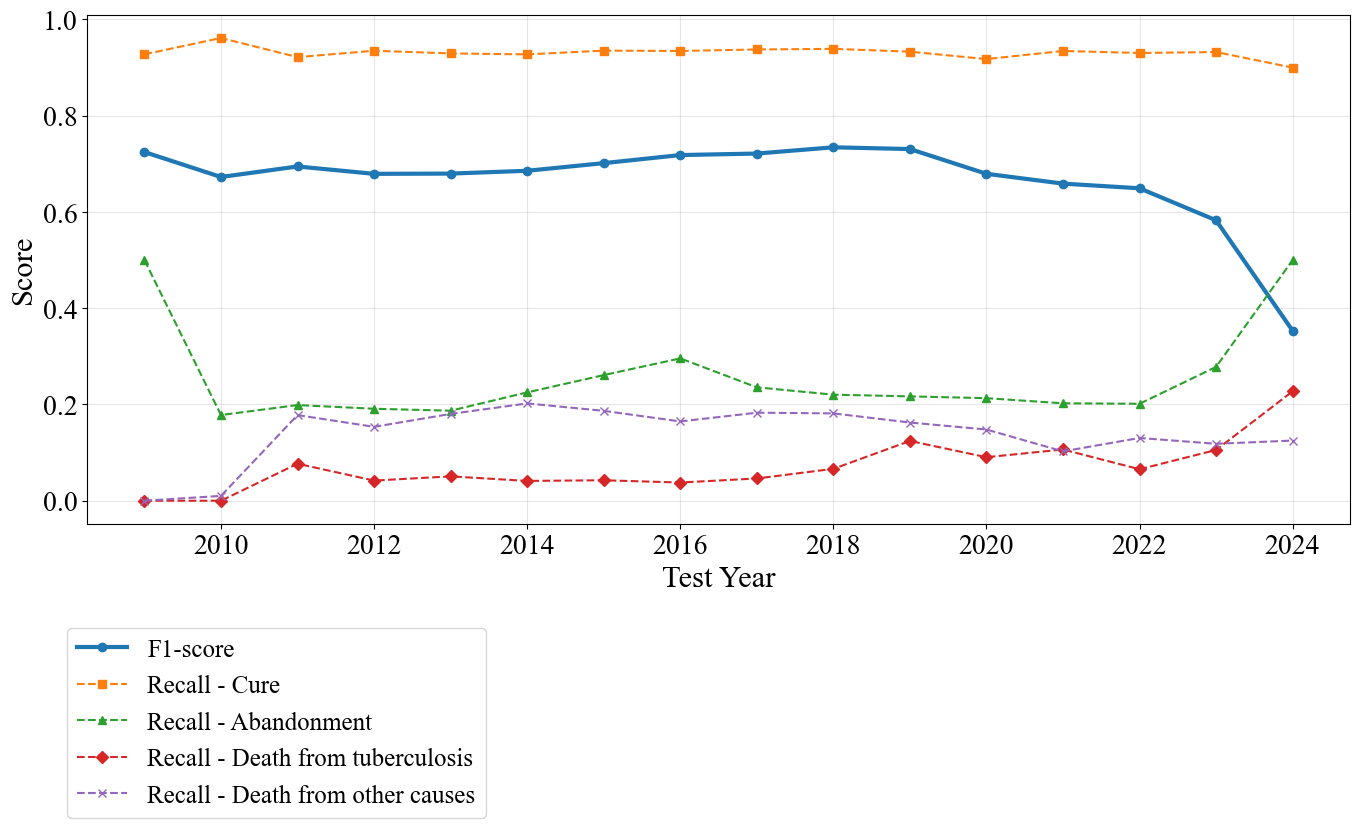

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unidecode
from sklearn.metrics import f1_score, recall_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from collections import Counter

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 20,
    "axes.titlesize": 22,
    "axes.labelsize": 22,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 18
})

df = pd.read_excel('dados_tuberculose_mg.xlsx')

def clean_text(x):
    if pd.isna(x):
        return x
    x = str(x).strip()
    x = unidecode.unidecode(x)
    x = x.replace(" ", "_")
    return x

for col in df.select_dtypes(include=["object", "str"]).columns:
    df[col] = df[col].apply(clean_text)

valid_classes = ["Cura", "Obito_por_TB", "Obito_por_outras_causas", "Abandono"]
df = df[df["SITUA_ENCE"].isin(valid_classes)].copy()

df["DT_DIAG"] = pd.to_datetime(df["DT_DIAG"], format="%d/%m/%Y", errors="coerce")
df["DT_INIC_TR"] = pd.to_datetime(df["DT_INIC_TR"], format="%d/%m/%Y", errors="coerce")

df["tempo_inicio_trat"] = (df["DT_INIC_TR"] - df["DT_DIAG"]).dt.days
df["tempo_inicio_trat"] = df["tempo_inicio_trat"].fillna(df["tempo_inicio_trat"].median())

df["YEAR"] = df["DT_DIAG"].dt.year

df = df.drop_duplicates().reset_index(drop=True)

high_card_cols = ["ID_MUNICIP", "ID_UNIDADE", "ID_MN_RESI"]

for col in high_card_cols:
    freq = df[col].value_counts(normalize=True)
    df[f"{col}_FREQ"] = df[col].map(freq)

cat_features = [
    "ID_REGIONA", "CS_SEXO", "CS_RACA", "CS_ESCOL_N", "TRATAMENTO",
    "CULTURA_ES", "HISTOPATOL", "FORMA", "AGRAVAIDS", "AGRAVALCOO",
    "AGRAVDIABE", "AGRAVDOENC", "AGRAVOUTRA", "HIV"
]

num_features = ["NU_IDADE_N", "tempo_inicio_trat"] + [f"{col}_FREQ" for col in high_card_cols]

features = cat_features + num_features

X = df[features]
y = df["SITUA_ENCE"]

le = LabelEncoder()
y_enc = pd.Series(le.fit_transform(y))

classes = list(le.classes_)
class_map = {c: i for i, c in enumerate(classes)}

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features),
        ("num", StandardScaler(), num_features)
    ]
)

years = sorted(df["YEAR"].dropna().unique())

f1_scores = []
recall_cure = []
recall_abandonment = []
recall_tb = []
recall_other = []
valid_years = []

for year in years[1:]:

    train_mask = df["YEAR"] < year
    test_mask  = df["YEAR"] == year

    if test_mask.sum() < 30:
        continue

    X_train = X[train_mask]
    X_test  = X[test_mask]

    y_train = y_enc[train_mask]
    y_test  = y_enc[test_mask]

    class_counts = Counter(y_train)
    min_class_size = min(class_counts.values())

    use_smote = min_class_size > 2

    steps = [("preprocess", preprocessor)]

    if use_smote:
        steps.append(("smote", SMOTE(
            random_state=43,
            k_neighbors=min(5, min_class_size - 1)
        )))

    steps.append(("rf", RandomForestClassifier(
        n_estimators=200,
        random_state=43,
        class_weight="balanced"
    )))

    model = ImbPipeline(steps)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    valid_years.append(year)

    f1_scores.append(f1_score(y_test, y_pred, average="weighted"))

    recall = recall_score(
        y_test, y_pred,
        average=None,
        labels=range(len(classes)),
        zero_division=0
    )

    recall_cure.append(recall[class_map.get("Cura", 0)])
    recall_abandonment.append(recall[class_map.get("Abandono", 0)])
    recall_tb.append(recall[class_map.get("Obito_por_TB", 0)])
    recall_other.append(recall[class_map.get("Obito_por_outras_causas", 0)])

plt.figure(figsize=(14,9))

plt.plot(valid_years, f1_scores, marker='o', linewidth=3, label="F1-score")
plt.plot(valid_years, recall_cure, marker='s', linestyle='--', label="Recall - Cure")
plt.plot(valid_years, recall_abandonment, marker='^', linestyle='--', label="Recall - Abandonment")
plt.plot(valid_years, recall_tb, marker='D', linestyle='--', label="Recall - Death from tuberculosis")
plt.plot(valid_years, recall_other, marker='x', linestyle='--', label="Recall - Death from other causes")

plt.xlabel("Test Year")
plt.ylabel("Score")

plt.grid(alpha=0.3)

plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.15, -0.18),
    ncol=1,
    frameon=True
)

plt.tight_layout()
plt.savefig("temporal_forward_validation.pdf", dpi=300)
plt.show()

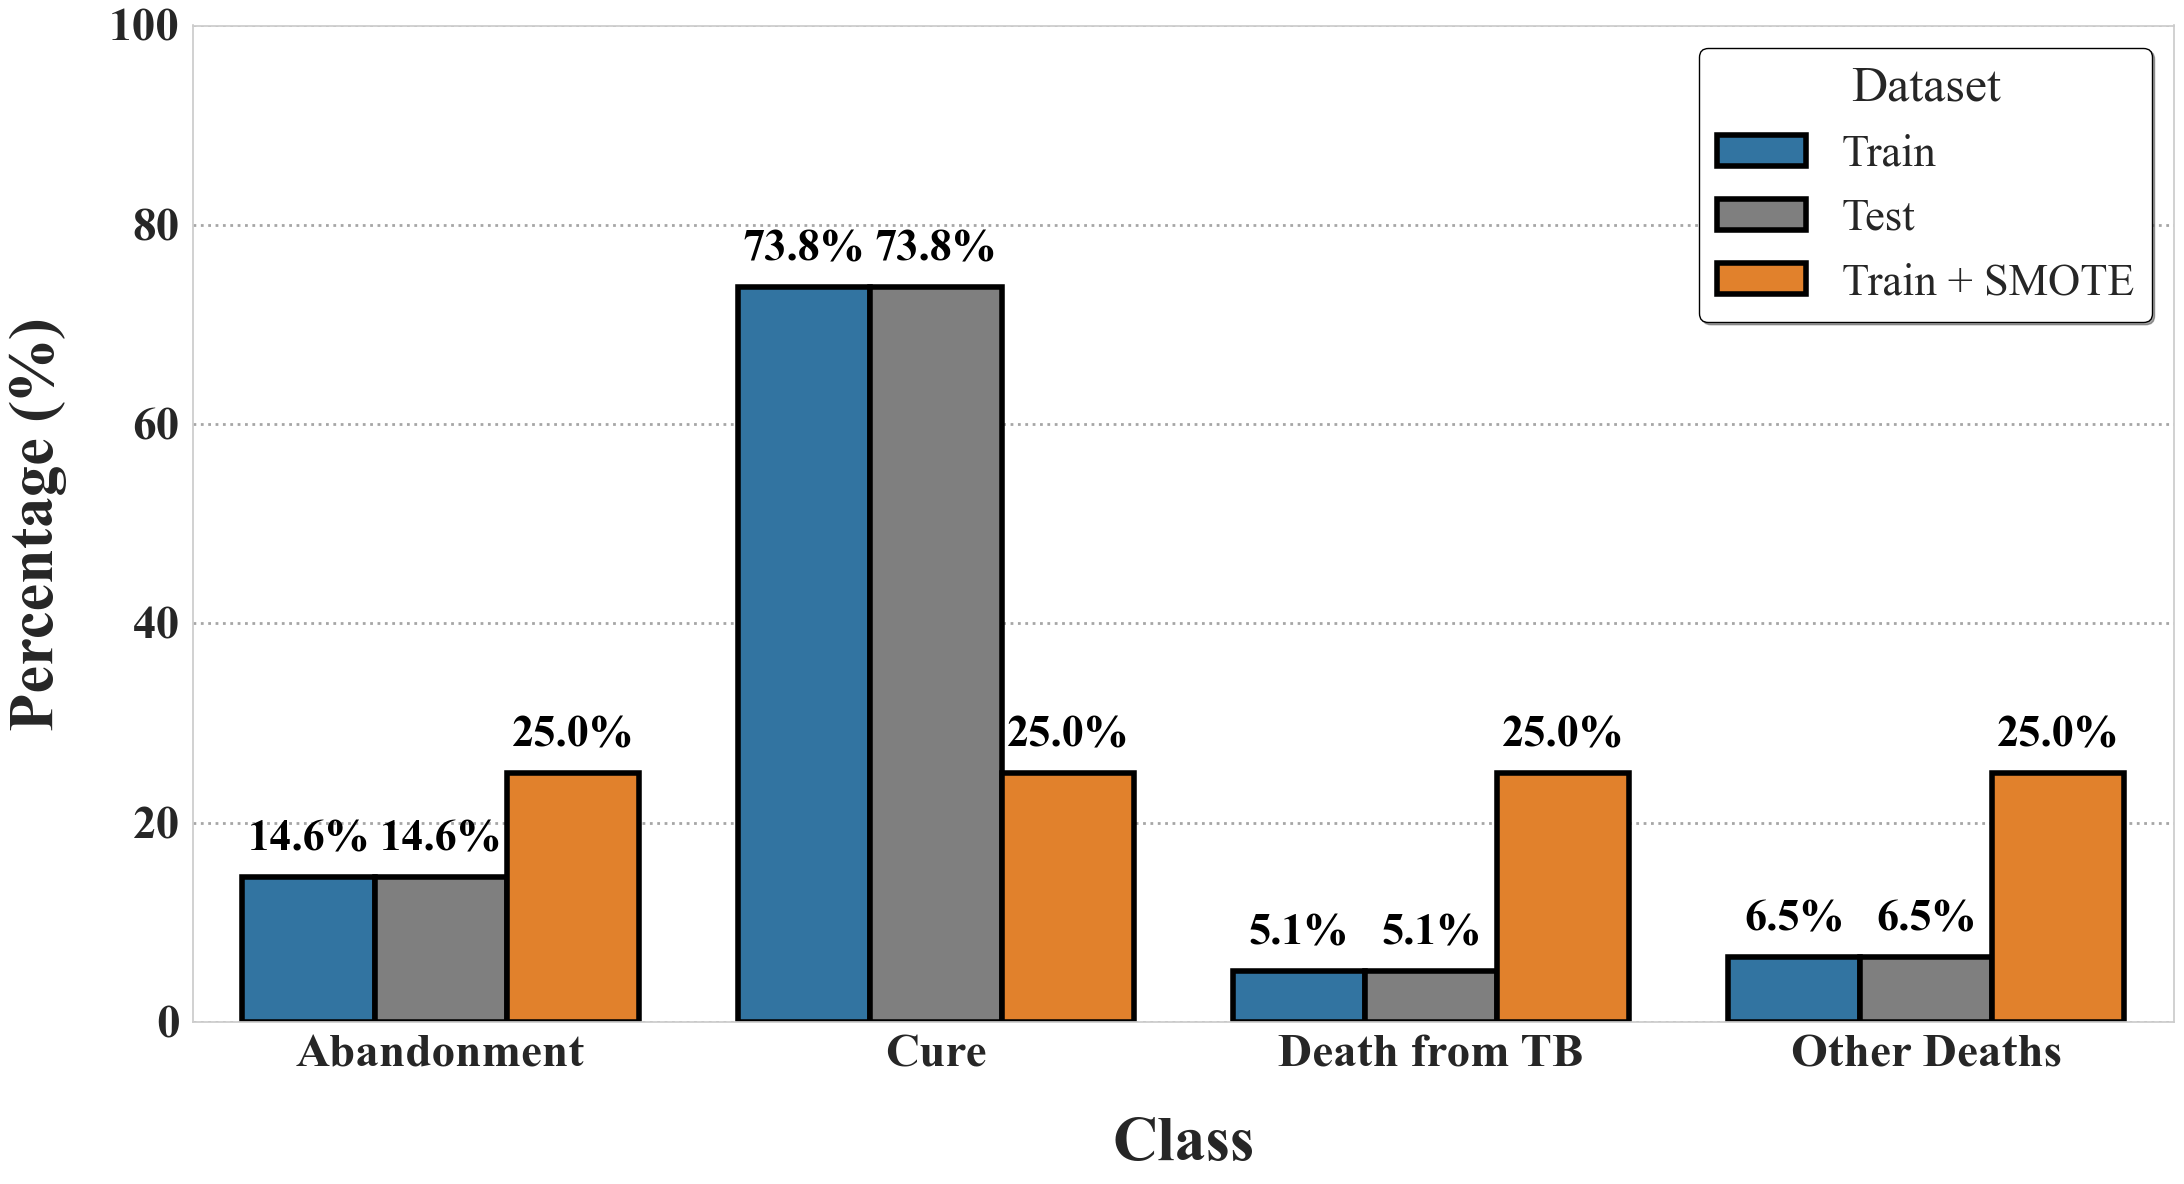

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib import rcParams
from imblearn.over_sampling import SMOTE

import unidecode
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

df = pd.read_excel('dados_tuberculose_mg.xlsx')

def limpar_texto(x):
    if pd.isna(x): return x
    x = str(x).strip()
    x = unidecode.unidecode(x)
    x = x.replace(" ", "_")
    return x

for col in df.select_dtypes(include=["object"]).columns:
    df[col] = df[col].apply(limpar_texto)

categorias_validas = ["Cura", "Obito_por_TB", "Obito_por_outras_causas", "Abandono"]
df_processado = df[df["SITUA_ENCE"].isin(categorias_validas)].copy()

df_processado["DT_DIAG"]    = pd.to_datetime(df_processado["DT_DIAG"],    format="%d/%m/%Y", errors="coerce")
df_processado["DT_INIC_TR"] = pd.to_datetime(df_processado["DT_INIC_TR"], format="%d/%m/%Y", errors="coerce")
df_processado["tempo_inicio_trat"] = (df_processado["DT_INIC_TR"] - df_processado["DT_DIAG"]).dt.days
df_processado = df_processado.drop_duplicates()
df_processado["tempo_inicio_trat"] = df_processado["tempo_inicio_trat"].fillna(df_processado["tempo_inicio_trat"].median())

colunas_alta_card = ["ID_MUNICIP", "ID_UNIDADE", "ID_MN_RESI"]
for col in colunas_alta_card:
    freq = df_processado[col].value_counts(normalize=True)
    df_processado[f"{col}_FREQ"] = df_processado[col].map(freq)

features_categoricas_baixa = [
    "ID_REGIONA", "CS_SEXO", "CS_RACA", "CS_ESCOL_N", "TRATAMENTO", "CULTURA_ES",
    "HISTOPATOL", "FORMA", "AGRAVAIDS", "AGRAVALCOO", "AGRAVDIABE",
    "AGRAVDOENC", "AGRAVOUTRA", "HIV"
]
features_numericas = ["NU_IDADE_N", "tempo_inicio_trat"] + [f"{col}_FREQ" for col in colunas_alta_card]

X = df_processado[features_categoricas_baixa + features_numericas]
y = df_processado["SITUA_ENCE"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=43, stratify=y
)

preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), features_categoricas_baixa),
    ("num", StandardScaler(), features_numericas)
])

class_names = {
    "Abandono": "Abandonment",
    "Cura": "Cure",
    "Obito_por_TB": "Death from TB",
    "Obito_por_outras_causas": "Other Deaths"
}

def get_class_distribution(y, label):
    classes, counts = np.unique(y, return_counts=True)
    pct = counts / counts.sum() * 100
    return pd.DataFrame({
        "Class": [class_names.get(cls, cls) for cls in classes],
        "Count": counts,
        "Percentage": pct,
        "Set": label
    })

df_train = get_class_distribution(y_train, "Train")
df_test  = get_class_distribution(y_test,  "Test")

X_train_transformed = preprocessor.fit_transform(X_train)
X_res, y_res = SMOTE(random_state=43).fit_resample(X_train_transformed, y_train)
df_smote = get_class_distribution(y_res, "Train + SMOTE")

df_plot = pd.concat([df_train, df_test, df_smote], axis=0)

sns.set(style="whitegrid")
rcParams['font.family'] = 'Times New Roman'

plt.figure(figsize=(22, 12))
order   = ["Abandonment", "Cure", "Death from TB", "Other Deaths"]
palette = {"Train": "#1f77b4", "Test": "#7f7f7f", "Train + SMOTE": "#ff7f0e"}

ax = sns.barplot(
    x="Class", y="Percentage", hue="Set",
    data=df_plot, palette=palette, order=order,
    edgecolor='black', linewidth=4
)

ax.yaxis.grid(True, ls=':', lw=2, color='gray', alpha=0.7)
ax.set_axisbelow(True)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        if height >= 98:
            va_pos, y_off, color = 'top', -15, 'white'
        else:
            va_pos, y_off, color = 'bottom', 12, 'black'
        ax.annotate(
            f'{height:.1f}%',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va=va_pos,
            fontsize=32, fontweight='black', color=color,
            xytext=(0, y_off), textcoords='offset points'
        )

plt.ylabel("Percentage (%)", fontsize=45, fontweight='bold', labelpad=30)
plt.xlabel("Class",          fontsize=45, fontweight='bold', labelpad=30)
plt.ylim(0, 100)
plt.xticks(fontsize=34, fontweight='bold')
plt.yticks(fontsize=34, fontweight='bold')
plt.legend(
    title="Dataset", title_fontsize=36, fontsize=32,
    loc="upper right", frameon=True, shadow=True, edgecolor='black'
)
plt.tight_layout()
plt.savefig("class_distribution_extreme_fonts.pdf", format="pdf", bbox_inches="tight")
plt.show()